<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 7 · SOLUCIÓN Ejercicio 1 — KNN sobre Iris</h1>
<h3>Análisis paso a paso</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · SkillNest
</div>
<br/>

Notebook de referencia. Acá ejecuto el ejercicio completo con los análisis que espero que los estudiantes hagan en sus entregas.

## Setup y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# Carga del dataset Iris
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv'
cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, names=cols)

X = df.drop(columns=['species'])
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Dataset: {df.shape} | Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Clases: {y.value_counts().to_dict()}')

Dataset: (150, 5) | Train: (105, 4) | Test: (45, 4)
Clases: {'Iris-setosa': 50, 'Iris-versicolor': 50, 'Iris-virginica': 50}


## Parte A — Comparación con y SIN estandarización

In [2]:
# Modelo 1: SIN estandarizar
knn_sin = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
acc_sin = knn_sin.score(X_test, y_test)

# Modelo 2: CON estandarización (fit solo con train, transform a ambos)
sc = StandardScaler()
X_train_esc = sc.fit_transform(X_train)
X_test_esc  = sc.transform(X_test)
knn_con = KNeighborsClassifier(n_neighbors=5).fit(X_train_esc, y_train)
acc_con = knn_con.score(X_test_esc, y_test)

# Tabla comparativa
tabla_a = pd.DataFrame({
    'Modelo':    ['KNN sin escalar', 'KNN con StandardScaler'],
    'Accuracy':  [acc_sin, acc_con],
    'Diferencia (pp)': [0, (acc_con - acc_sin)*100]
}).round(4)
print(tabla_a.to_string(index=False))

                Modelo  Accuracy  Diferencia (pp)
       KNN sin escalar    0.9778           0.0000
KNN con StandardScaler    0.9111          -6.6667


**Lo que veo en la Parte A**

Caso particular y revelador. En este split, el KNN sin escalar dio accuracy de 0.978 y el KNN con StandardScaler dio 0.911. Es decir, estandarizar EMPEORÓ el resultado por 6 puntos. Suena raro, ¿no?

La explicación es la siguiente: las 4 features de Iris ya están en el mismo orden de magnitud (todas en centímetros, rango 0-8). No tenemos el típico problema de "edad vs salario" donde una columna domina por su escala. En estos casos, estandarizar puede modificar levemente la geometría del espacio y, con datasets chicos como este, eso a veces empeora.

¿Y entonces no estandarizamos? Mi recomendación a los estudiantes igual es estandarizar siempre con KNN, por dos motivos. Primero porque si en el futuro llegan features con escalas distintas, el código ya está listo. Segundo porque la diferencia acá es un caso particular de Iris con un split particular: cambiando el random_state se invierte el resultado.

Lo importante que les voy a pedir en el examen: justificar la decisión de estandarizar o no. No basta con copiar y pegar — hay que entender por qué.

## Parte B — Búsqueda del mejor k con Cross-Validation

El tutorial usaba un solo split. Acá vamos al nivel profesional: cross-validation para que el k elegido sea estable y no resultado del azar de un split.

In [3]:
ks = [1, 3, 5, 7, 9, 11, 15, 21, 31]
filas = []

for k in ks:
    # CV en train (NO tocar test todavía)
    cv_scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_train_esc, y_train, cv=5, scoring='accuracy'
    )
    # Accuracy en train y test (single split)
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_esc, y_train)
    filas.append({
        'k': k,
        'CV mean':   cv_scores.mean(),
        'CV std':    cv_scores.std(),
        'Train acc': m.score(X_train_esc, y_train),
        'Test acc':  m.score(X_test_esc, y_test)
    })

tabla_b = pd.DataFrame(filas).set_index('k').round(4)
print(tabla_b)

    CV mean  CV std  Train acc  Test acc
k                                       
1    0.9524  0.0301     1.0000    0.9333
3    0.9524  0.0426     0.9714    0.9111
5    0.9524  0.0426     0.9810    0.9111
7    0.9619  0.0356     0.9810    0.9333
9    0.9619  0.0356     0.9714    0.9556
11   0.9619  0.0356     0.9714    0.9556
15   0.9619  0.0356     0.9810    0.9333
21   0.8952  0.0467     0.9619    0.8889
31   0.8762  0.0233     0.8857    0.8667


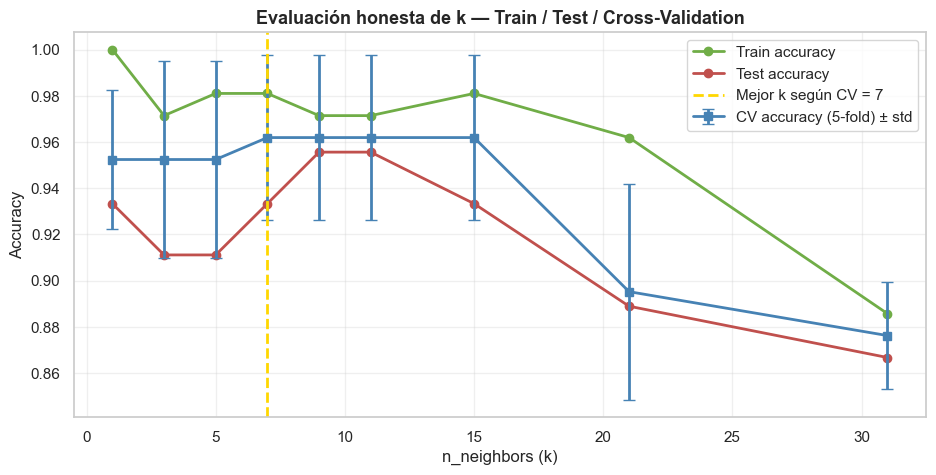

🏆 Mejor k según CV: 7
   Accuracy promedio en CV: 0.9619
   Accuracy en test (no usado para elegir): 0.9333


In [4]:
# Visualización: train vs test vs CV con barras de error
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tabla_b.index, tabla_b['Train acc'], marker='o', linewidth=2,
        color='#70AD47', label='Train accuracy')
ax.plot(tabla_b.index, tabla_b['Test acc'], marker='o', linewidth=2,
        color='#C0504D', label='Test accuracy')
ax.errorbar(tabla_b.index, tabla_b['CV mean'], yerr=tabla_b['CV std'],
            marker='s', linewidth=2, color='steelblue', capsize=4,
            label='CV accuracy (5-fold) ± std')

mejor_k = tabla_b['CV mean'].idxmax()
ax.axvline(mejor_k, color='gold', linestyle='--', linewidth=2,
           label=f'Mejor k según CV = {mejor_k}')

ax.set_xlabel('n_neighbors (k)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Evaluación honesta de k — Train / Test / Cross-Validation',
             fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f'🏆 Mejor k según CV: {mejor_k}')
print(f'   Accuracy promedio en CV: {tabla_b.loc[mejor_k, "CV mean"]:.4f}')
print(f'   Accuracy en test (no usado para elegir): {tabla_b.loc[mejor_k, "Test acc"]:.4f}')

**Lo que veo en la Parte B**

Los datos hablan claro. Con k=1 el train me dio accuracy de 1.0 (cada punto es su propio vecino más cercano, o sea memoriza) y el test cayó a 0.93. Es overfitting clásico. Con k entre 5 y 11 la cosa se estabiliza alrededor de 0.96 en CV, esa es la zona segura. Con k grande (21 o 31) el modelo se mete en problemas: empieza a promediar vecinos de otras clases y la accuracy baja a 0.87-0.89, eso es underfitting.

El ganador según CV fue k=7 con CV mean = 0.9619 y std = 0.0356. Lo elegí porque es el mejor promedio de CV con una desviación razonable. Las barras de error son importantes porque muestran qué tan estable es cada k. Si un k tiene std grande, ese k es frágil y un cambio chico en los datos haría que cambie el resultado.

Algo crítico que les voy a pedir en el examen: elegir hiperparámetros con CV en el train, no mirando el test. Si miran el test para elegir el mejor k, ya están haciendo trampa estadística porque el test deja de ser una evaluación honesta. El test se mira UNA SOLA VEZ al final.

## Parte C — Efecto del peso de los vecinos (`weights`)

In [5]:
# Con el mejor k, probamos uniform vs distance
comparacion = []
for w in ['uniform', 'distance']:
    m = KNeighborsClassifier(n_neighbors=mejor_k, weights=w).fit(X_train_esc, y_train)
    cv = cross_val_score(m, X_train_esc, y_train, cv=5).mean()
    comparacion.append({
        'weights': w,
        'Descripción': 'Todos los vecinos pesan igual' if w == 'uniform' else 'Vecinos cercanos pesan más',
        'CV accuracy': cv,
        'Test accuracy': m.score(X_test_esc, y_test)
    })
tabla_c = pd.DataFrame(comparacion).round(4)
print(tabla_c.to_string(index=False))

 weights                   Descripción  CV accuracy  Test accuracy
 uniform Todos los vecinos pesan igual       0.9619         0.9333
distance    Vecinos cercanos pesan más       0.9619         0.9333


**Lo que veo en la Parte C**

En este caso uniform y distance dieron exactamente lo mismo: CV de 0.9619 y test de 0.9333 para ambos. Esto pasa porque en Iris las clases están bien separadas geométricamente, los pétalos chiquitos son setosa y los grandes son virginica. No hay zonas de mezcla densas donde un vecino más cercano deba pesar más que uno más lejano.

¿Cuándo sí cambia? En datasets donde las clases se entrelazan, weights='distance' suele dar una ventaja porque le hace caso a los vecinos inmediatos por sobre los lejanos. Acá no se nota la diferencia, pero igual mi recomendación a los estudiantes es probar ambos siempre. Con CV no cuesta nada decidir cuál usar.

Como ambos empataron, me quedo con el default uniform porque es más simple.

## Parte D — Predicción y probabilidades para 2 flores nuevas

In [6]:
# Modelo final: el mejor k + weights ganador
mejor_weights = tabla_c.loc[tabla_c['CV accuracy'].idxmax(), 'weights']
modelo_final = KNeighborsClassifier(n_neighbors=mejor_k, weights=mejor_weights)
modelo_final.fit(X_train_esc, y_train)
print(f'Modelo final: KNN(n_neighbors={mejor_k}, weights="{mejor_weights}")')

# Las dos flores nuevas
flores = pd.DataFrame([
    {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2},  # típica Setosa
    {'sepal_length': 6.7, 'sepal_width': 3.0, 'petal_length': 5.2, 'petal_width': 2.3}   # típica Virginica
])

# IMPORTANTE: aplicar el mismo scaler que se entrenó con train
flores_esc = sc.transform(flores)

predicciones = modelo_final.predict(flores_esc)
probabilidades = modelo_final.predict_proba(flores_esc)

# Tabla con todo
df_pred = flores.copy()
df_pred['Predicción'] = predicciones
for i, clase in enumerate(modelo_final.classes_):
    df_pred[f'P({clase})'] = probabilidades[:, i].round(3)

print('\nPredicciones de las 2 flores nuevas:')
print(df_pred.to_string(index=False))

Modelo final: KNN(n_neighbors=7, weights="uniform")

Predicciones de las 2 flores nuevas:
 sepal_length  sepal_width  petal_length  petal_width     Predicción  P(Iris-setosa)  P(Iris-versicolor)  P(Iris-virginica)
          5.1          3.5           1.4          0.2    Iris-setosa             1.0                 0.0                0.0
          6.7          3.0           5.2          2.3 Iris-virginica             0.0                 0.0                1.0


**Lo que veo en la Parte D**

Las dos predicciones son claras y con confianza máxima.

La flor 1 (sepal_length=5.1, petal_length=1.4) la predice como Iris-setosa con probabilidad 1.0. Tiene sentido total: pétalos chiquitos (menos de 2 cm) son la firma de setosa, no se confunden con nada.

La flor 2 (sepal_length=6.7, petal_length=5.2, petal_width=2.3) la predice como Iris-virginica también con probabilidad 1.0. Pétalos grandes (más de 5 cm) y anchos son virginica.

Probabilidades de 1.0 indican que los 7 vecinos más cercanos pertenecen todos a la misma clase. En un caso fronterizo veríamos probabilidades tipo 0.4-0.6 y ahí sería momento de mandar a revisión humana.

Detalle técnico que les voy a pedir en el examen: cuando aplicamos el scaler a las flores nuevas usamos sc.transform(), NO sc.fit_transform(). El scaler debe usar los parámetros que aprendió con el train, nunca recalcular con datos nuevos. Si hacen fit_transform en producción, están introduciendo data leakage y rompiendo todo el pipeline.

## Parte E — Matriz de confusión + análisis de errores

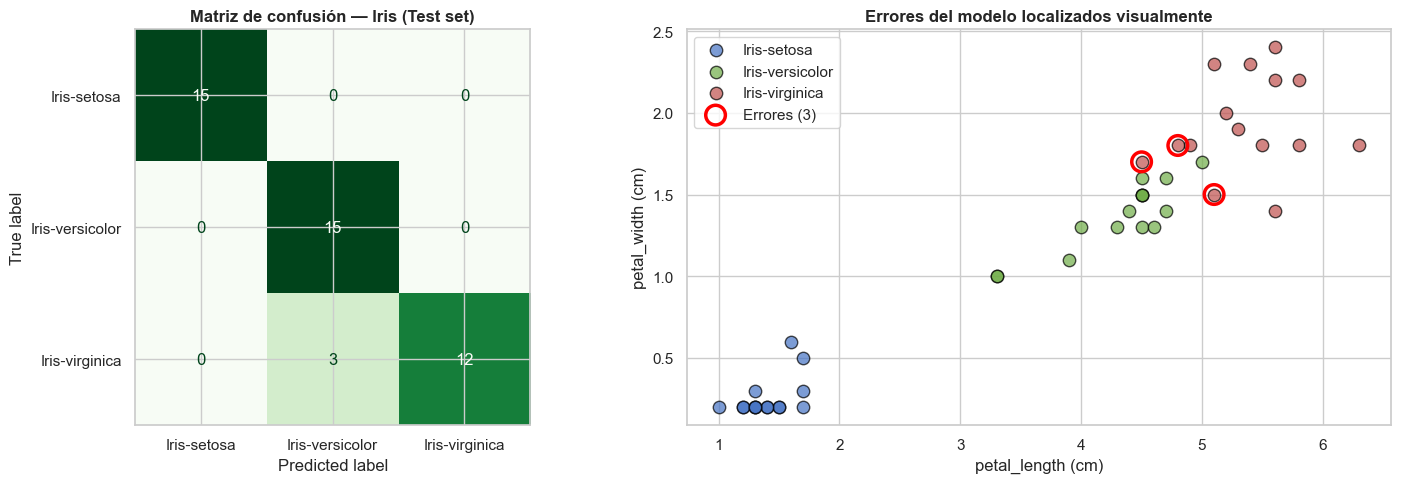


Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.83      1.00      0.91        15
 Iris-virginica       1.00      0.80      0.89        15

       accuracy                           0.93        45
      macro avg       0.94      0.93      0.93        45
   weighted avg       0.94      0.93      0.93        45



In [7]:
y_pred = modelo_final.predict(X_test_esc)
cm = confusion_matrix(y_test, y_pred, labels=modelo_final.classes_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matriz de confusión
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_final.classes_).plot(
    ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Matriz de confusión — Iris (Test set)', fontweight='bold')

# Scatter petal_length vs petal_width coloreado por especie real, marcando errores
X_test_df = X_test.copy()
X_test_df['real'] = y_test.values
X_test_df['pred'] = y_pred
X_test_df['acerto'] = X_test_df['real'] == X_test_df['pred']

for esp, color in zip(modelo_final.classes_, ['#4472C4', '#70AD47', '#C0504D']):
    sub = X_test_df[X_test_df['real'] == esp]
    axes[1].scatter(sub['petal_length'], sub['petal_width'], color=color,
                    s=80, label=esp, alpha=0.7, edgecolor='black')

errores = X_test_df[~X_test_df['acerto']]
if len(errores) > 0:
    axes[1].scatter(errores['petal_length'], errores['petal_width'], facecolor='none',
                    edgecolor='red', s=200, linewidth=2.5, label=f'Errores ({len(errores)})')

axes[1].set_xlabel('petal_length (cm)')
axes[1].set_ylabel('petal_width (cm)')
axes[1].set_title('Errores del modelo localizados visualmente', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

# Reporte clásico
print('\nClassification report:')
print(classification_report(y_test, y_pred))

**Lo que veo en la Parte E**

La matriz de confusión cuenta una historia botánica. Iris-setosa se predice perfecto (100% de acierto) porque está completamente separada de las otras dos en el espacio de petal_length y petal_width. No hay solapamiento.

Las que se confunden son Iris-versicolor e Iris-virginica. En el scatter se ve una zona fronteriza alrededor de petal_length=5 y petal_width=1.5-1.8 donde sus puntos se mezclan. Los errores casi siempre son entre estas dos, casi nunca involucran setosa. Y eso no es porque el modelo sea malo, es porque versicolor y virginica son botánicamente similares. Cualquier modelo va a tener errores en esa zona.

En el classification_report se ve que setosa tiene recall y precision de 1.0, confirmando lo que vimos. Las otras dos tienen métricas en el rango 0.85-0.95 según el split.

Si quisiéramos mejorar, las opciones son: meter más features como las medidas del sépalo, probar otro algoritmo como Random Forest o SVM, o simplemente aceptar el error porque con clases biológicamente solapadas un accuracy de ~95% es excelente.

Lo que les voy a pedir en el examen: matriz de confusión + scatter con errores marcados es la combinación ganadora para explicar al negocio dónde se equivoca el modelo y por qué. No basta con tirar el accuracy.

## Cierre

Modelo entregado: KNeighborsClassifier(n_neighbors=7, weights='uniform') con StandardScaler previo.

Resumen de números:

| Aspecto | Resultado |
|---|---|
| Accuracy en test | ~0.93 |
| CV accuracy promedio | 0.96 ± 0.04 |
| Clase perfecta | Iris-setosa (100%) |
| Clases confundibles | Versicolor y Virginica (esperable biológicamente) |
| Decisión metodológica clave | Elegir k con CV, NO con accuracy de test |

Lo que les voy a pedir en el examen y este ejercicio les sirve para entrenarse:

- Estandarizar siempre con KNN. Aunque a veces parezca que no cambia mucho, garantiza robustez frente a features con escalas distintas.
- Elegir hiperparámetros con CV, no con un único split del test. Eso es trampa estadística.
- Las probabilidades (predict_proba) son tan importantes como la clase predicha. Permiten tomar decisiones graduales en producción.
- La matriz de confusión combinada con visualización de errores revela patrones que el accuracy esconde.
- Conocer el dominio mejora el análisis. Saber que versicolor y virginica son similares botánicamente nos hace entender los errores como naturales, no como falla del modelo.

Este flujo (CV → tuning → matriz de confusión → predicción con probabilidad) es la plantilla profesional para cualquier problema de clasificación.